# sc-GEM Analysis

In [1]:
cd /home/mscs/congfeng4/GuidedStudy/Code/SCOIT/

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'sc_GEM'
FEATURE = 'walk'

In [3]:
cell_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_0.npy')
gene_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_1.npy')
omics_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.unique(pd.read_csv("data/sc_GEM/cell_stage.csv", header=None))
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [4]:
cell_stage, len(cell_stage)

(array(['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8'],
       dtype=object),
 8)

In [5]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_1', 'BJ_11', 'BJ_12', 'BJ_13', 'BJ_14', 'BJ_15', 'BJ_17',
       'BJ_18', 'BJ_19', 'BJ_2', 'BJ_21', 'BJ_22', 'BJ_23', 'BJ_24',
       'BJ_25', 'BJ_26', 'BJ_27', 'BJ_28', 'BJ_29', 'BJ_3', 'BJ_31',
       'BJ_32', 'BJ_34', 'BJ_35', 'BJ_37', 'BJ_4', 'BJ_40', 'BJ_41',
       'BJ_43', 'BJ_44', 'BJ_46', 'BJ_5', 'BJ_7', 'BJ_8', 'BJ_9', 'ES_1',
       'ES_10', 'ES_11', 'ES_12', 'ES_13', 'ES_14', 'ES_15', 'ES_16',
       'ES_17', 'ES_18', 'ES_19', 'ES_2', 'ES_20', 'ES_21', 'ES_22',
       'ES_24', 'ES_25', 'ES_3', 'ES_4', 'ES_5', 'ES_6', 'ES_7', 'ES_8',
       'ES_9', 'IPS_1', 'IPS_10', 'IPS_11', 'IPS_12', 'IPS_13', 'IPS_16',
       'IPS_17', 'IPS_19', 'IPS_2', 'IPS_20', 'IPS_21', 'IPS_22',
       'IPS_23', 'IPS_24', 'IPS_25', 'IPS_26', 'IPS_27', 'IPS_3',
       'IPS_31', 'IPS_32', 'IPS_34', 'IPS_35', 'IPS_36', 'IPS_37',
       'IPS_38', 'IPS_39', 'IPS_4', 'IPS_40', 'IPS_44', 'IPS_45', 'IPS_5',
       'IPS_6', 'IPS_7', 'IPS_8', 'd16T+_1', 'd16T+_10', 'd16T+_11',
       'd16T+_12', 'd

In [6]:
def find_cell_stage(cell_id):
    for stage in cell_stage:
        if stage in cell_id:
            return stage
    return '??'

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [7]:
cell_stage_from_id

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16

In [8]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

for stage, name in zip(cell_stage_from_id, cell_names):
    assert stage in name, f'stage={stage}, name={name}'

In [9]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

Text(0, 0.5, 'UMAP_2')

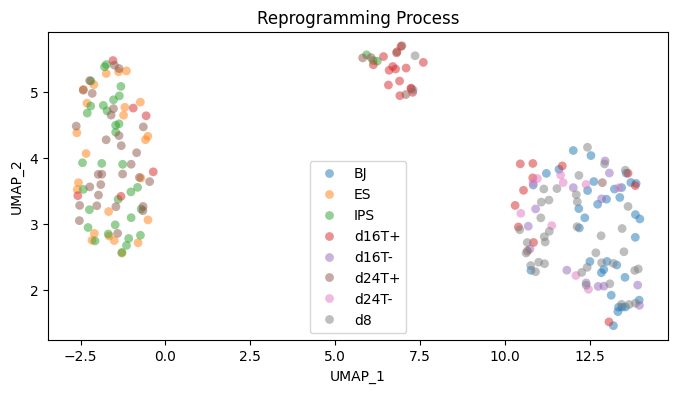

In [11]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('Reprogramming Process')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

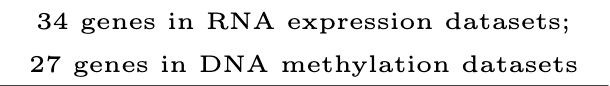

In [12]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,HAND1_expr,IGF2_expr,JARID2_expr,KCNQ2_expr,LEFTY_expr,LUM_expr,MMP9_expr,MYC_expr,NANOG_expr,NESTIN_expr,NKX2-5_expr,OCT4_expr,OTX2_expr,PRDM14_expr,SALL4_expr,SOX2_expr,TBX3_expr,TFAP2A_expr,TFCP2L1_expr,TGFBR2_expr,WNT10B_expr,ZFP42_expr,ZIC3_expr,ZSCAN18_expr,ADAM33_methy,AK123759_methy,ALDH3A1_methy,CDH22_methy,CHL1_methy,COL20A1_methy,COL23A1_methy,CYBRD1_methy,DPPA3_methy,EPHB3_methy,FOXD2_methy,HLX-AS1_methy,KCNQ2_methy,LTBR_methy,LY86-AS1_methy,NFATC1_methy,NFIX_methy,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,0.146701,0.128782,0.096764,0.139299,0.073414,0.698644,0.099218,0.094009,0.112159,0.082989,0.059628,0.086252,0.097237,0.133626,0.105274,0.101465,0.124566,0.097422,0.138733,0.067358,0.164475,0.109678,0.100126,0.109956,0.122502,0.118006,0.095388,0.106933,0.109477,0.054110,0.074001,0.093699,0.117510,0.094471,0.146123,0.141702,0.144640,0.181181,0.164084,0.146725,0.129736,0.146640,0.158223,0.146749,0.138025,0.137672,0.162825,0.167062,0.159384,0.133229,0.134201,0.166049,0.173400,0.148491,0.146073,0.147287,0.141479,0.170826,0.151153,0.163162,0.130362
1,-0.100759,-0.163375,-0.164612,-0.140705,-0.113680,0.042511,-0.211600,-0.205623,-0.110150,-0.285150,-0.299815,-0.284849,-0.199686,-0.133014,-0.265504,-0.332215,-0.087202,-0.263542,-0.148400,-0.334159,-0.103588,-0.135068,-0.190148,-0.134638,-0.198848,-0.228111,-0.307569,-0.317343,-0.057641,-0.301330,-0.190547,-0.166755,-0.130895,-0.127304,-0.193014,-0.193540,-0.044116,-0.063672,-0.071027,-0.090262,-0.163294,-0.106956,-0.038463,-0.211281,-0.220165,-0.222905,-0.048551,-0.052931,-0.166314,-0.215019,-0.210562,-0.067618,-0.070433,-0.191698,-0.094440,-0.084144,-0.224144,-0.040728,-0.064303,-0.071923,-0.115275
2,0.275082,0.235584,0.216490,0.209427,0.171209,0.581494,0.201737,0.235769,0.234881,0.292329,0.338343,0.310394,0.270814,0.211134,0.302865,0.341522,0.201328,0.271014,0.257126,0.316130,0.282514,0.180168,0.212781,0.197815,0.229281,0.251935,0.337891,0.327539,0.193491,0.354195,0.256147,0.205500,0.159441,0.192004,0.327301,0.329010,0.233295,0.246022,0.245621,0.260464,0.349920,0.276549,0.230210,0.361002,0.347476,0.360514,0.229766,0.195999,0.346847,0.326755,0.369773,0.205891,0.202936,0.360565,0.235773,0.247912,0.387869,0.241294,0.257115,0.235526,0.266938
3,0.171718,0.097741,0.088983,0.106291,0.129541,0.631287,0.142419,0.157918,0.087861,0.199203,0.164789,0.164005,0.143753,0.088112,0.136331,0.170477,0.049065,0.167767,0.117772,0.152520,0.162580,0.136301,0.135867,0.090122,0.170568,0.146010,0.195701,0.193300,0.092255,0.181458,0.158171,0.061441,0.120441,0.146455,0.150551,0.156848,0.179961,0.151815,0.181883,0.180407,0.170951,0.152676,0.152178,0.148837,0.134733,0.132734,0.157953,0.179426,0.150792,0.145765,0.137872,0.159647,0.166728,0.138447,0.183870,0.173475,0.126403,0.175511,0.180150,0.171739,0.156837
4,-0.085670,0.131998,0.145490,-0.009670,0.024692,-0.755884,0.156991,-0.015705,0.077024,0.055550,0.055542,0.052645,0.134301,0.140967,0.115518,0.082165,0.123570,0.126991,0.142570,0.038612,-0.082752,0.049767,0.133208,0.127212,0.128385,0.111620,0.095524,0.063896,0.089798,0.047197,0.020273,0.156773,0.158861,0.036246,-0.090232,-0.116725,-0.090738,-0.067913,-0.075340,-0.085948,-0.117460,-0.104886,-0.052525,-0.096129,-0.114397,-0.140930,-0.091409,-0.084793,-0.103529,-0.071445,-0.114932,-0.096606,-0.068235,-0.093869,-0.074113,-0.079349,-0.101295,-0.055310,-0.093360,-0.088125,-0.079606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.023482,-0.002817,-0.023865,0.000756,0.004046,0.328488,-0.029999,0.106685,-0.005074,-0.067634,-0.008088,-0.016421,-0.039692,0.007622,-0.006796,-0.002536,0.024935,-0.095814,0.010026,-

In [13]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [14]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

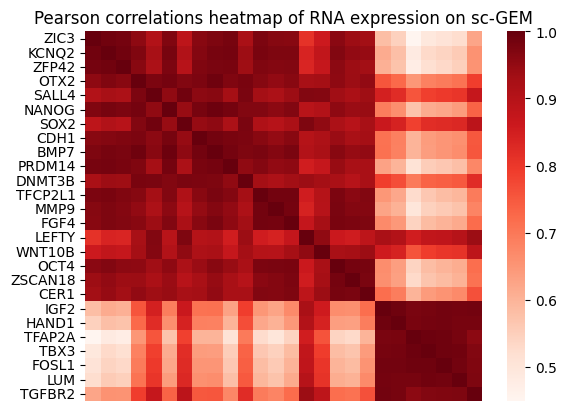

In [15]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [16]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

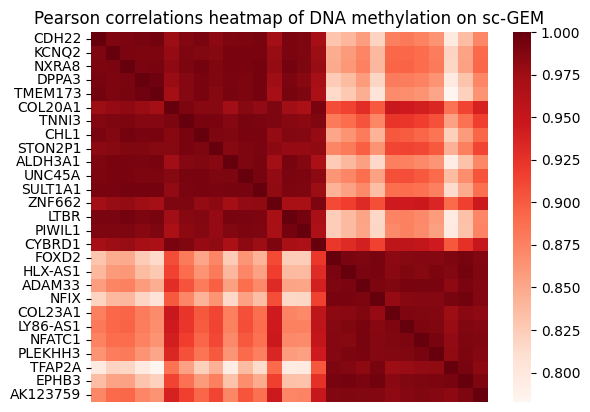

In [17]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [18]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [19]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [20]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [21]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [22]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [23]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [24]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [25]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,1.113576
1,BJ,TFAP2A,1.150314
2,BJ,TFAP2A,1.103441
3,BJ,TFAP2A,1.092116
4,BJ,TFAP2A,1.087973
...,...,...,...
1115,d8,TGFBR2,1.100231
1116,d8,TGFBR2,1.108776
1117,d8,TGFBR2,1.061827
1118,d8,TGFBR2,1.081262


Text(0, 0.5, 'Projection value')

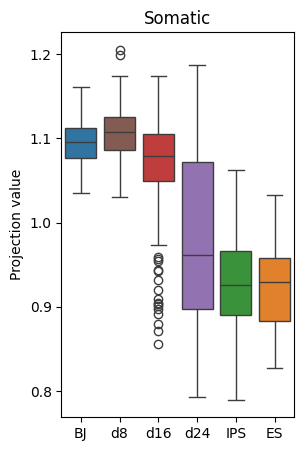

In [26]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [27]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,0.937633
1,BJ,ZIC3,0.852532
2,BJ,ZIC3,0.944583
3,BJ,ZIC3,0.876058
4,BJ,ZIC3,0.997195
...,...,...,...
4251,d8,CER1,1.080613
4252,d8,CER1,1.062895
4253,d8,CER1,1.015988
4254,d8,CER1,0.952541


Text(0, 0.5, 'Projection value')

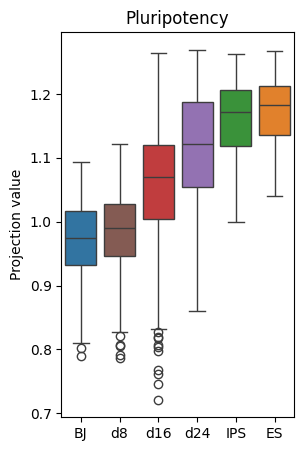

In [28]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [29]:
cell_embeddings.shape

(224, 64)

In [ ]:
from sklearn.cluster import k_means

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings / cell_norms), n_clusters=len(cell_stage))
cluster.shape

(224,)

In [31]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}

In [32]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [33]:
from scipy.optimize import linear_sum_assignment

k = len(cell_stage)
y = cell_stage_label
cluster_ids = cluster

def align_cluster(cluster_ids, y, k):
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((k, k), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [34]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [35]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [36]:
y_pred_aligned = align_cluster(cluster, cell_stage_label, len(cell_stage))

In [37]:
metrics = compute_clustering_metrics(y, y_pred_aligned)
metrics


{'NMI': 0.35978131051951867,
 'ARI': 0.17412964118406585,
 'FMI': 0.29131644247981386}

### Baselines

t-SNE, PCA, UMAP.

In [44]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [39]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [ ]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009735345840454102
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,HAND1_expr,IGF2_expr,JARID2_expr,KCNQ2_expr,LEFTY_expr,LUM_expr,MMP9_expr,MYC_expr,NANOG_expr,NESTIN_expr,NKX2-5_expr,OCT4_expr,OTX2_expr,PRDM14_expr,SALL4_expr,SOX2_expr,TBX3_expr,TFAP2A_expr,TFCP2L1_expr,TGFBR2_expr,WNT10B_expr,ZFP42_expr,ZIC3_expr,ZSCAN18_expr,ADAM33_methy,AK123759_methy,ALDH3A1_methy,CDH22_methy,CHL1_methy,COL20A1_methy,COL23A1_methy,CYBRD1_methy,DPPA3_methy,EPHB3_methy,FOXD2_methy,HLX-AS1_methy,KCNQ2_methy,LTBR_methy,LY86-AS1_methy,NFATC1_methy,NFIX_methy,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
Cell ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BJ_1,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.728549,0.000000,0.000000,11.339771,0.0,0.0,15.676021,0.0,17.672202,0.000000,0.000000,0.0,0.0,0.000000,0.0,4.113456,0.000000,18.862732,18.263900,0.0,0.000000,0.000000,0.0,0.0,0.0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,0
BJ_11,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.601503,0.000000,0.000000,0.000000,0.0,0.0,14.837929,0.0,17.923791,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,20.198281,19.781943,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0
BJ_12,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,15.460834,0.000000,0.000000,14.112148,0.0,0.0,0.000000,0.0,17.893047,0.000000,4.826607,0.0,0.0,0.000000,0.0,0.000000,0.000000,19.193395,18.370780,0.0,4.767891,0.000000,0.0,0.0,0.0,1,0,0,0,1,1,1,0,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,1,1,0,0
BJ_13,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.178236,0.000000,0.000000,0.000000,0.0,0.0,16.516569,0.0,20.464720,0.000000,8.418421,0.0,0.0,0.000000,0.0,0.000000,8.111852,21.272866,17.711377,0.0,0.000000,0.000000,0.0,0.0,0.0,1,0,0,0,1,0,1,0,0,1,1,1,1,0,1,1,1,0,0,1,0,0,1,0,0,0,0
BJ_14,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,17.713610,0.000000,0.000000,0.000000,0.0,0.0,19.545398,0.0,19.270543,0.000000,2.752524,0.0,0.0,0.000000,0.0,9.019616,0.000000,19.588199,20.853982,0.0,4.419259,8.796303,0.0,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,1,1,1,0,0,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d8_46,0.0,0.0,18.865629,0.0,0.0,0.0,15.397756,19.233267,0.0,0.000000,17.288448,17.469698,0.000000,0.0,0.0,0.000000,0.0,24.366972,0.000000,11.291259,0.0,0.0,0.000000,0.0,0.000000,0.000000,18.700552,18.570520,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,1,1,0,1,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0
d8_5,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.115367,0.000000,11.432820,17.093213,0.0,0.0,0.000000,0.0,24.101037,3.935607,13.656141,0.0,0.0,12.391728,0.0,11.596348,0.000000,16.747477,21.641471,0.0,5.239673,0.000000,0.0,0.0,0.0,1,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,1,0
d8_7,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,11.767016,0.000000,0.0,0.0,0.000000,0.0,21.850392,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,14.592632,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,0,1,0,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1,0,0,0,0


In [41]:
assert (create.df.index == cell_names).all().all()


In [42]:
features = create.df.values
features.shape

(224, 61)

In [ ]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []

    for name, method in baselines.items():
        print(name)
        if method is None:
            x = cell_embeddings
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label, k)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label, k)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


Text(0, 0.5, 'UMAP_2')

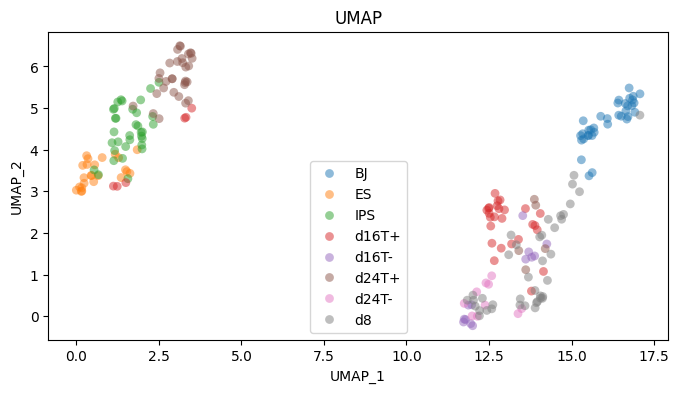

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

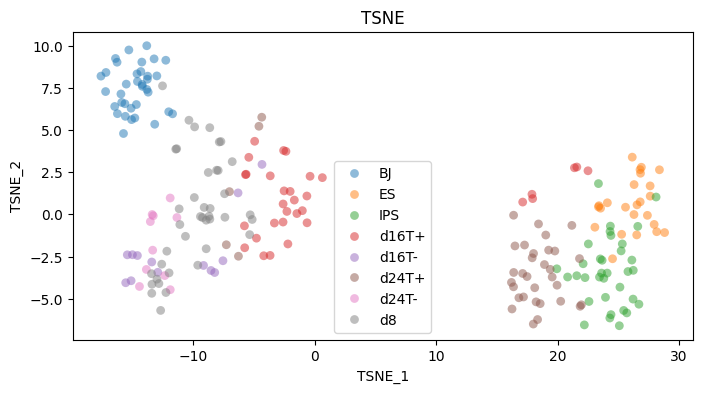

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")


### K-means performance

In [51]:
df_cluster = run_baselines(features, cell_embeddings)

TSNE
PCA
UMAP
Ours


Text(0, 0.5, '')

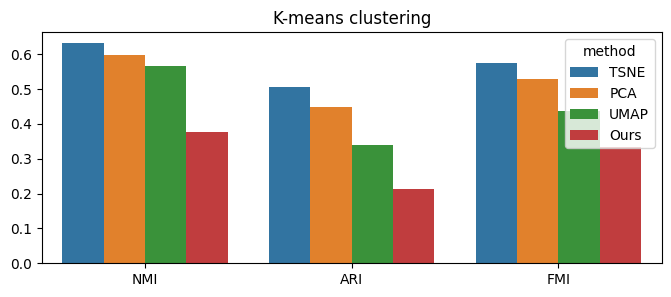

In [52]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

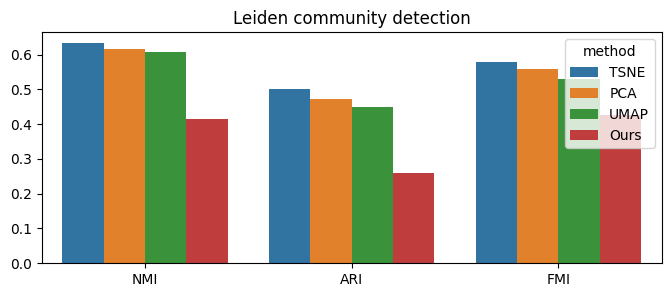

In [53]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')